# Split Learning vs Full 5-Layer Model on MNIST

This notebook compares:

1. **A standard full 5-layer neural network**
2. **A split learning version of the same network** with:

   * **Client:** first 2 layers
   * **Server:** last 3 layers

The goal is to check whether, under controlled conditions, the split model behaves the same as the full model.

We compare:

* training and test accuracy
* training and test loss
* training time
* layer-by-layer weight equality
* layer-by-layer weight closeness
* maximum absolute difference between corresponding weights

This notebook uses:

* **MNIST**
* **1 client**
* **IID / standard training data**

That gives the cleanest possible equivalence test.

---

## Cell 1 - Imports

In [1]:
NOTEBOOK_ID = "03"

import os

BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")

RESULTS_DIR = os.path.join(BASE_DIR, "results")

CSV_DIR = os.path.join(RESULTS_DIR, "csv", NOTEBOOK_ID)

PLOTS_DIR = os.path.join(RESULTS_DIR, "plots", NOTEBOOK_ID)

WEIGHTS_DIR = os.path.join(BASE_DIR, "weights", NOTEBOOK_ID)

FL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "fl")

SFL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "sfl")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(FL_WEIGHTS_DIR, exist_ok=True)
os.makedirs(SFL_WEIGHTS_DIR, exist_ok=True)


In [2]:
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Cell 2 - Reproducibility and Device Setup

This section fixes the random seed so that:

model initialization is repeatable
data shuffling is repeatable
results are easier to compare fairly

In [3]:
def set_seed(seed: int = 42):
    """
    Fix random seeds across Python, NumPy, and PyTorch so that the
    experiment is reproducible.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Cell 3 - Hyperparameters

This section stores the main experiment settings in one place.

In [4]:
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256
LEARNING_RATE = 0.01
EPOCHS = 50
SEED = 42

Cell 4 - Load MNIST Data

We use MNIST because it is simple, fast, and stable for an equivalence test.

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

# Use a manually seeded generator so the batch order is reproducible.
train_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 60000
Test samples:  10000


Cell 5 - Full 5-Layer Model

This model is the non-split baseline.

Architecture:

Flatten
Linear 784 -> 256
ReLU
Linear 256 -> 128
ReLU
Linear 128 -> 64
ReLU
Linear 64 -> 32
ReLU
Linear 32 -> 10

The learnable layers are the 5 linear layers.

In [6]:
class FullModel(nn.Module):
    """
    Standard full 5-layer feedforward model.

    The five trainable layers are:
    - fc1
    - fc2
    - fc3
    - fc4
    - fc5
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)
        x = self.fc5(x)
        return x

Cell 6 - Split Learning Models

The split version divides the same architecture into two parts:

Client
fc1
ReLU
fc2
ReLU
Server
fc3
ReLU
fc4
ReLU
fc5

When combined, this should represent the same overall model as the full network.

In [7]:
class ClientModel(nn.Module):
    """
    Client-side part of the split network.

    This contains the first two trainable layers of the full model.
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        return x


class ServerModel(nn.Module):
    """
    Server-side part of the split network.

    This contains the last three trainable layers of the full model.
    """
    def __init__(self):
        super().__init__()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.relu4(x)
        x = self.fc5(x)
        return x

Cell 7 - Weight Synchronization Utilities

To make a fair comparison, the corresponding layers in the full and split models must start with the exact same initial weights.

In [8]:
def copy_full_to_split(full_model: FullModel, client_model: ClientModel, server_model: ServerModel):
    """
    Copy the weights from the full model into the corresponding client and server layers.
    This guarantees that both approaches start from the same initialization.
    """
    client_model.fc1.weight.data.copy_(full_model.fc1.weight.data)
    client_model.fc1.bias.data.copy_(full_model.fc1.bias.data)

    client_model.fc2.weight.data.copy_(full_model.fc2.weight.data)
    client_model.fc2.bias.data.copy_(full_model.fc2.bias.data)

    server_model.fc3.weight.data.copy_(full_model.fc3.weight.data)
    server_model.fc3.bias.data.copy_(full_model.fc3.bias.data)

    server_model.fc4.weight.data.copy_(full_model.fc4.weight.data)
    server_model.fc4.bias.data.copy_(full_model.fc4.bias.data)

    server_model.fc5.weight.data.copy_(full_model.fc5.weight.data)
    server_model.fc5.bias.data.copy_(full_model.fc5.bias.data)

Cell 8 - Layer Comparison Helpers

These functions compare corresponding layers between the full and split models.

In [9]:
def compare_tensors(t1: torch.Tensor, t2: torch.Tensor, atol: float = 1e-7, rtol: float = 1e-5):
    """
    Compare two tensors using:
    - exact equality
    - allclose
    - maximum absolute difference
    - mean absolute difference
    """
    exact_equal = torch.equal(t1, t2)
    close_equal = torch.allclose(t1, t2, atol=atol, rtol=rtol)
    abs_diff = (t1 - t2).abs()
    max_abs_diff = abs_diff.max().item()
    mean_abs_diff = abs_diff.mean().item()

    return {
        "exact_equal": exact_equal,
        "allclose": close_equal,
        "max_abs_diff": max_abs_diff,
        "mean_abs_diff": mean_abs_diff,
    }


def compare_full_vs_split_weights(full_model: FullModel, client_model: ClientModel, server_model: ServerModel):
    """
    Compare each full-model trainable layer with its corresponding split-model layer.
    Returns a list of dictionaries for easy display.
    """
    comparisons = [] # this list will hold the comparison results for each layer, where each entry is a dictionary containing the layer name and the results of the comparison (exact equality, allclose, max absolute difference, mean absolute difference)

    layer_pairs = [  # this list defines the pairs of layers to compare, where each entry is a tuple containing the layer name, the full model tensor, and the corresponding split model tensor (either from the client or server model depending on which part of the full model it corresponds to)
        ("fc1.weight", full_model.fc1.weight, client_model.fc1.weight),
        ("fc1.bias",   full_model.fc1.bias,   client_model.fc1.bias),
        ("fc2.weight", full_model.fc2.weight, client_model.fc2.weight),
        ("fc2.bias",   full_model.fc2.bias,   client_model.fc2.bias),
        ("fc3.weight", full_model.fc3.weight, server_model.fc3.weight),
        ("fc3.bias",   full_model.fc3.bias,   server_model.fc3.bias),
        ("fc4.weight", full_model.fc4.weight, server_model.fc4.weight),
        ("fc4.bias",   full_model.fc4.bias,   server_model.fc4.bias),
        ("fc5.weight", full_model.fc5.weight, server_model.fc5.weight),
        ("fc5.bias",   full_model.fc5.bias,   server_model.fc5.bias),
    ]

    for name, full_tensor, split_tensor in layer_pairs:
        result = compare_tensors(full_tensor.detach().cpu(), split_tensor.detach().cpu())
        result["layer"] = name
        comparisons.append(result)
    # comparison is a list of dictionaries where each dictionary contains the results of comparing one layer from the full model to its corresponding layer in the split model, including whether they are exactly equal, whether they are close within a certain tolerance, and the maximum and mean absolute differences between the tensors
    return pd.DataFrame(comparisons)

Cell 9 - Evaluation Function

This function is used for both the full model and the combined split model.

In [10]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    """
    Evaluate a model on a dataset loader.

    Returns:
    - average loss
    - accuracy
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

Cell 10 - Combined Split Wrapper for Evaluation

During training, the split model runs as client then server. For evaluation convenience, we define a wrapper that makes the split model behave like one model.

In [11]:
class CombinedSplitModel(nn.Module):
    """
    Convenience wrapper used only for evaluation.
    It chains the client and server models together.
    """
    def __init__(self, client_model: ClientModel, server_model: ServerModel):
        super().__init__()
        self.client_model = client_model
        self.server_model = server_model

    def forward(self, x):
        smashed_data = self.client_model(x)
        logits = self.server_model(smashed_data)
        return logits

Cell 11 - Full Model Training Function

This trains the full 5-layer model in the normal way.

In [12]:
def train_full_model(model: FullModel, train_loader: DataLoader, test_loader: DataLoader, epochs: int, lr: float, device: torch.device):
    """
    Train the standard full model.

    Tracks:
    - train loss
    - train accuracy
    - test loss
    - test accuracy
    - epoch time
    - total time
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    model.to(device)
    history = []

    start_total = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_start = time.perf_counter() # this variable will be used to measure the time taken for each epoch, which includes the training loop and the evaluation on the test set, it is initialized at the beginning of each epoch and then the elapsed time is calculated at the end of the epoch to track how long each epoch takes

        running_loss = 0.0 # this variable accumulates the total loss for the epoch, it is updated in each iteration of the training loop by adding the loss for the current batch multiplied by the number of samples in that batch (to get the total loss contribution from that batch), at the end of the epoch, this running loss will be divided by the total number of samples to get the average training loss for the epoch
        correct = 0 # this variable counts the total number of correct predictions across all batches in the epoch, it is updated in each iteration of the training loop by comparing the predicted labels (obtained by taking the argmax of the logits) to the true labels and summing up the number of matches, at the end of the epoch, this correct count will be divided by the total number of samples to get the training accuracy for the epoch
        total = 0 # this variable counts the total number of samples processed in the epoch, it is updated in each iteration of the training loop by adding the number of samples in the current batch, at the end of the epoch, this total count will be used to calculate the average training loss and accuracy

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y.size(0) # y.size(0) is the batch size, multiplying the loss by the batch size gives the total loss contribution from that batch, which is accumulated in running_loss to later compute the average loss for the epoch
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total # this calculates the average training loss for the epoch by dividing the accumulated running loss by the total number of samples processed in the epoch
        train_acc = correct / total # this calculates the training accuracy for the epoch by dividing the number of correct predictions by the total number of samples      
        test_loss, test_acc = evaluate_model(model, test_loader, device)
        epoch_time = time.perf_counter() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "epoch_time_sec": epoch_time,
        })

        print(
            f"[Full] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    total_time = time.perf_counter() - start_total
    return pd.DataFrame(history), total_time

Cell 12 - Split Model Training Function

This trains the split model as:

client forward pass
server forward pass
compute loss on server
backpropagate through server
send gradient of smashed data back to client
backpropagate through client
update both optimizers

In [13]:
def train_split_model(client_model: ClientModel, server_model: ServerModel,
                      train_loader: DataLoader, test_loader: DataLoader,
                      epochs: int, lr: float, device: torch.device):
    """
    Train the split learning model with one client and one server.

    The client computes the first two layers.
    The server computes the last three layers.

    We explicitly pass gradients across the split boundary.
    """
    criterion = nn.CrossEntropyLoss()

    # Optimizers for client-side and server-side parameters
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr)
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr)

    client_model.to(device)
    server_model.to(device)

    history = []
    start_total = time.perf_counter()

    for epoch in range(1, epochs + 1):
        client_model.train()
        server_model.train()
        epoch_start = time.perf_counter()

        running_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            # ---------- Client forward ----------
            smashed_data = client_model(x)

            # Detach and re-enable gradients so that the split boundary is explicit
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            # ---------- Server forward ----------
            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)

            # ---------- Server backward ----------
            loss.backward()

            # Gradient to send back from server to client
            grad_to_client = smashed_data_detached.grad.clone()

            # Update server parameters
            server_optimizer.step()

            # ---------- Client backward ----------
            smashed_data.backward(grad_to_client)
            client_optimizer.step()

            running_loss += loss.item() * y.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        combined_model = CombinedSplitModel(client_model, server_model).to(device)
        test_loss, test_acc = evaluate_model(combined_model, test_loader, device)
        epoch_time = time.perf_counter() - epoch_start

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "epoch_time_sec": epoch_time,
        })

        print(
            f"[Split] Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | "
            f"time={epoch_time:.2f}s"
        )

    total_time = time.perf_counter() - start_total
    return pd.DataFrame(history), total_time

Cell 13 - Initialize Models Fairly

We create one full model, then copy its weights into the split client and split server so the experiment starts fairly.

In [14]:
set_seed(SEED)

full_model = FullModel()
client_model = ClientModel()
server_model = ServerModel()

copy_full_to_split(full_model, client_model, server_model)

print("Initial layer comparison:")
initial_compare_df = compare_full_vs_split_weights(full_model, client_model, server_model)
display(initial_compare_df)

Initial layer comparison:


,exact_equal,allclose,max_abs_diff,mean_abs_diff,layer
0,True,True,0.0,0.0,fc1.weight
1,True,True,0.0,0.0,fc1.bias
2,True,True,0.0,0.0,fc2.weight
3,True,True,0.0,0.0,fc2.bias
4,True,True,0.0,0.0,fc3.weight
5,True,True,0.0,0.0,fc3.bias
6,True,True,0.0,0.0,fc4.weight
7,True,True,0.0,0.0,fc4.bias
8,True,True,0.0,0.0,fc5.weight
9,True,True,0.0,0.0,fc5.bias


Cell 14 - Train Both Models

Important note: To keep the comparison fair, both models should see the same data order. Since a DataLoader iterator is consumed during training, we rebuild the training loader before each run using the same seed.

In [15]:
def make_train_loader(seed: int):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

# Recreate loaders so both models use the same shuffled batch order.
train_loader_full = make_train_loader(SEED)
train_loader_split = make_train_loader(SEED)

# Fresh models for fair training comparison
set_seed(SEED)
full_model = FullModel()
client_model = ClientModel()
server_model = ServerModel()
copy_full_to_split(full_model, client_model, server_model)

full_history, full_total_time = train_full_model(
    model=full_model,
    train_loader=train_loader_full,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
)

split_history, split_total_time = train_split_model(
    client_model=client_model,
    server_model=server_model,
    train_loader=train_loader_split,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
)

[Full] Epoch 01 | train_loss=2.3030 | train_acc=0.1136 | test_loss=2.2962 | test_acc=0.1028 | time=3.28s
[Full] Epoch 02 | train_loss=2.2828 | train_acc=0.2210 | test_loss=2.2523 | test_acc=0.3694 | time=3.05s
[Full] Epoch 03 | train_loss=1.8377 | train_acc=0.4788 | test_loss=1.0565 | test_acc=0.6409 | time=3.15s
[Full] Epoch 04 | train_loss=0.7958 | train_acc=0.7470 | test_loss=0.6196 | test_acc=0.8199 | time=2.83s
[Full] Epoch 05 | train_loss=0.5561 | train_acc=0.8379 | test_loss=0.5084 | test_acc=0.8540 | time=3.20s
[Full] Epoch 06 | train_loss=0.4286 | train_acc=0.8790 | test_loss=0.3659 | test_acc=0.8958 | time=3.11s
[Full] Epoch 07 | train_loss=0.3391 | train_acc=0.9043 | test_loss=0.3029 | test_acc=0.9121 | time=3.13s
[Full] Epoch 08 | train_loss=0.2797 | train_acc=0.9208 | test_loss=0.2641 | test_acc=0.9237 | time=3.06s
[Full] Epoch 09 | train_loss=0.2381 | train_acc=0.9328 | test_loss=0.2251 | test_acc=0.9321 | time=3.04s
[Full] Epoch 10 | train_loss=0.2070 | train_acc=0.9415 

Cell 15 - Compare Final Weights

This is one of the most important outputs for your supervisor.

In [16]:
print("Final layer comparison:")
final_compare_df = compare_full_vs_split_weights(full_model, client_model, server_model)
display(final_compare_df)

Final layer comparison:


,exact_equal,allclose,max_abs_diff,mean_abs_diff,layer
0,True,True,0.0,0.0,fc1.weight
1,True,True,0.0,0.0,fc1.bias
2,True,True,0.0,0.0,fc2.weight
3,True,True,0.0,0.0,fc2.bias
4,True,True,0.0,0.0,fc3.weight
5,True,True,0.0,0.0,fc3.bias
6,True,True,0.0,0.0,fc4.weight
7,True,True,0.0,0.0,fc4.bias
8,True,True,0.0,0.0,fc5.weight
9,True,True,0.0,0.0,fc5.bias


Cell 16 - Show Accuracy and Loss History

In [17]:
print("Full model history:")
display(full_history)

print("Split model history:")
display(split_history)

Full model history:


,epoch,train_loss,train_acc,test_loss,test_acc,epoch_time_sec
0,1,2.302985,0.113617,2.296171,0.1028,3.281141
1,2,2.282756,0.220950,2.252330,0.3694,3.052004
2,3,1.837701,0.478750,1.056458,0.6409,3.147466
3,4,0.795786,0.746983,0.619612,0.8199,2.827004
4,5,0.556097,0.837950,0.508447,0.8540,3.197722
5,6,0.428589,0.879000,0.365940,0.8958,3.110163
6,7,0.339056,0.904317,0.302941,0.9121,3.133036
7,8,0.279730,0.920817,0.264050,0.9237,3.060541
8,9,0.238103,0.932850,0.225093,0.9321,3.036231
9,10,0.207026,0.941450,0.197814,0.9439,3.034591


Split model history:


,epoch,train_loss,train_acc,test_loss,test_acc,epoch_time_sec
0,1,2.302985,0.113617,2.296171,0.1028,3.289951
1,2,2.282756,0.220950,2.252330,0.3694,3.164716
2,3,1.837701,0.478750,1.056458,0.6409,3.331196
3,4,0.795786,0.746983,0.619612,0.8199,3.324620
4,5,0.556097,0.837950,0.508447,0.8540,3.421149
5,6,0.428589,0.879000,0.365940,0.8958,3.242064
6,7,0.339056,0.904317,0.302941,0.9121,3.356718
7,8,0.279730,0.920817,0.264050,0.9237,3.178625
8,9,0.238103,0.932850,0.225093,0.9321,3.321754
9,10,0.207026,0.941450,0.197814,0.9439,3.186116


Cell 17 - Time Comparison

In [18]:
time_df = pd.DataFrame([
    {"model": "Full 5-layer model", "total_time_sec": full_total_time, "avg_epoch_time_sec": full_history["epoch_time_sec"].mean()},
    {"model": "Split model (2 client + 3 server)", "total_time_sec": split_total_time, "avg_epoch_time_sec": split_history["epoch_time_sec"].mean()},
])

display(time_df)

,model,total_time_sec,avg_epoch_time_sec
0,Full 5-layer model,153.048035,3.060862
1,Split model (2 client + 3 server),160.456227,3.209027


Cell 18 - Plot Accuracy Comparison

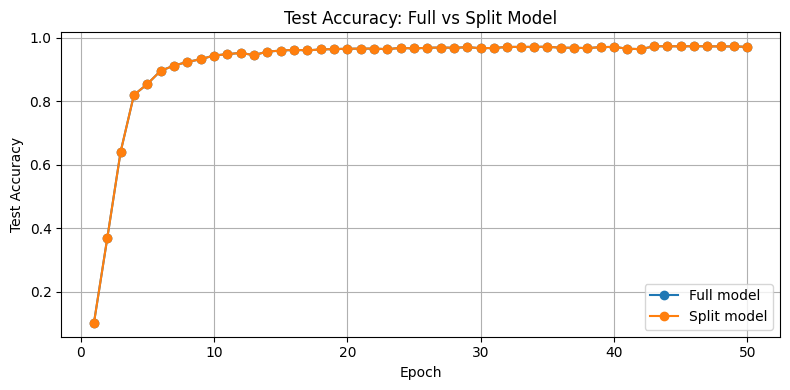

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(full_history["epoch"], full_history["test_acc"], marker="o", label="Full model")
plt.plot(split_history["epoch"], split_history["test_acc"], marker="o", label="Split model")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy: Full vs Split Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Cell 19 - Plot Loss Comparison

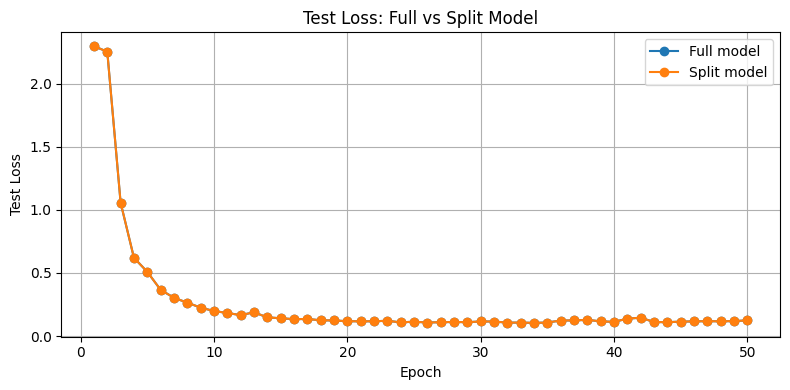

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(full_history["epoch"], full_history["test_loss"], marker="o", label="Full model")
plt.plot(split_history["epoch"], split_history["test_loss"], marker="o", label="Split model")
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss: Full vs Split Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Cell 20 - Plot Training Time per Epoch

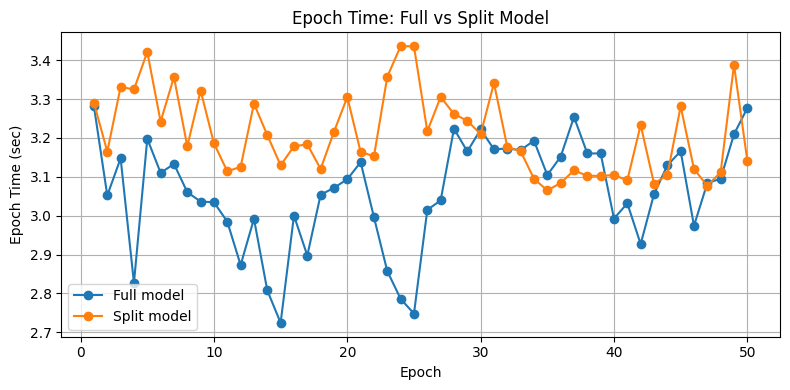

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(full_history["epoch"], full_history["epoch_time_sec"], marker="o", label="Full model")
plt.plot(split_history["epoch"], split_history["epoch_time_sec"], marker="o", label="Split model")
plt.xlabel("Epoch")
plt.ylabel("Epoch Time (sec)")
plt.title("Epoch Time: Full vs Split Model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()